In [ ]:
# Step 1: Clone fresh
%cd /content
!rm -rf gaussian-splatting
!git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting.git
%cd /content/gaussian-splatting

# Step 2: Verify files exist
!ls submodules/

# Step 3: Install with correct python and no isolation
!python -m pip install --no-build-isolation submodules/diff-gaussian-rasterization
!python -m pip install --no-build-isolation submodules/simple-knn
!python -m pip install --no-build-isolation submodules/fused-ssim

print("DONE")

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.71 MiB | 14.40 MiB/s, done.
Resolving deltas: 100% (593/593), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects:

In [ ]:
!pip install -q plyfile imageio imageio-ffmpeg tqdm

In [ ]:
import os
os.makedirs("data/room/images", exist_ok=True)

from google.colab import files
uploaded = files.upload()
# rename whatever you uploaded to room.mp4
import shutil
filename = list(uploaded.keys())[0]
shutil.move(filename, "data/room/room.mp4")
print("Video ready:", filename)

Saving WhatsApp Video 2026-02-20 at 22.40.02.mp4 to WhatsApp Video 2026-02-20 at 22.40.02.mp4
Video ready: WhatsApp Video 2026-02-20 at 22.40.02.mp4


In [ ]:
!ffmpeg -i data/room/room.mp4 -vf "fps=3" data/room/images/frame_%04d.jpg
!echo "Frames extracted:"
!ls data/room/images/ | wc -l

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
!apt-get install -y colmap
!colmap --version  # verify it works

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libamd2 libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libcamd2 libccolamd2 libceres2
  libcholmod3 libcolamd2 libcxsparse3 libdouble-conversion3 libevdev2
  libfreeimage3 libgflags2.2 libglew2.2 libgoogle-glog0v5 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libilmbase25 libinput-bin
  libinput10 libjxr0 libmd4c0 libmetis5 libmtdev1 libopenexr25 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libraw20
  librsvg2-common libspqr2 libsuitesparseconfig5 libwacom-bin libwacom-common
  libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0
  libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qt5-gtk-platformtheme qttranslations5-l10n
  session-migration
Suggested packages:
  gle

In [ ]:
!rm -f data/room/database.db

In [ ]:
!rm -f data/room/database.db

!QT_QPA_PLATFORM=offscreen colmap feature_extractor \
    --database_path data/room/database.db \
    --image_path data/room/images \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0

!QT_QPA_PLATFORM=offscreen colmap exhaustive_matcher \
    --database_path data/room/database.db \
    --SiftMatching.use_gpu 0

!mkdir -p data/room/sparse

!QT_QPA_PLATFORM=offscreen colmap mapper \
    --database_path data/room/database.db \
    --image_path data/room/images \
    --output_path data/room/sparse


Feature extraction

Processed file [1/48]
  Name:            frame_0001.jpg
  Dimensions:      478 x 850
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1020.00px
  Features:        2640
Processed file [2/48]
  Name:            frame_0002.jpg
  Dimensions:      478 x 850
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1020.00px
  Features:        2923
Processed file [3/48]
  Name:            frame_0004.jpg
  Dimensions:      478 x 850
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1020.00px
  Features:        2712
Processed file [4/48]
  Name:            frame_0003.jpg
  Dimensions:      478 x 850
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1020.00px
  Features:        3096
Processed file [5/48]
  Name:            frame_0005.jpg
  Dimensions:      478 x 850
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    1020.00px
  Features:        2724
Processed file [6/48]
  Name:            frame_0006.jpg
  Dimensions:      478 x 850
  Camera:     

In [ ]:
!ls data/room/
!ls data/room/sparse/

database.db  distorted	images	room.mp4  sparse
0


In [ ]:
!mkdir -p data/room/undistorted

!QT_QPA_PLATFORM=offscreen colmap image_undistorter \
    --image_path data/room/images \
    --input_path data/room/sparse/0 \
    --output_path data/room/undistorted \
    --output_type COLMAP

!python train.py \
    -s /content/gaussian-splatting/data/room/undistorted \
    -m output_room \
    --iterations 7000


Reading reconstruction

 => Reconstruction with 48 images and 7495 points

Image undistortion

Undistorting image [1/48]
Undistorting image [2/48]
Undistorting image [3/48]
Undistorting image [4/48]
Undistorting image [5/48]
Undistorting image [6/48]
Undistorting image [7/48]
Undistorting image [8/48]
Undistorting image [9/48]
Undistorting image [10/48]
Undistorting image [11/48]
Undistorting image [12/48]
Undistorting image [13/48]
Undistorting image [14/48]
Undistorting image [15/48]
Undistorting image [16/48]
Undistorting image [17/48]
Undistorting image [18/48]
Undistorting image [19/48]
Undistorting image [20/48]
Undistorting image [21/48]
Undistorting image [22/48]
Undistorting image [23/48]
Undistorting image [24/48]
Undistorting image [25/48]
Undistorting image [26/48]
Undistorting image [27/48]
Undistorting image [28/48]
Undistorting image [29/48]
Undistorting image [30/48]
Undistorting image [31/48]
Undistorting image [32/48]
Undistorting image [33/48]
Undistorting image [34

In [ ]:
!find data/room/undistorted -not -name "*.jpg" | sort

data/room/undistorted
data/room/undistorted/images
data/room/undistorted/run-colmap-geometric.sh
data/room/undistorted/run-colmap-photometric.sh
data/room/undistorted/sparse
data/room/undistorted/sparse/cameras.bin
data/room/undistorted/sparse/images.bin
data/room/undistorted/sparse/points3D.bin
data/room/undistorted/stereo
data/room/undistorted/stereo/consistency_graphs
data/room/undistorted/stereo/depth_maps
data/room/undistorted/stereo/fusion.cfg
data/room/undistorted/stereo/normal_maps
data/room/undistorted/stereo/patch-match.cfg


In [ ]:
!mkdir -p data/room/undistorted/sparse/0
!mv data/room/undistorted/sparse/cameras.bin data/room/undistorted/sparse/0/
!mv data/room/undistorted/sparse/images.bin data/room/undistorted/sparse/0/
!mv data/room/undistorted/sparse/points3D.bin data/room/undistorted/sparse/0/

# Now train
!python train.py \
    -s /content/gaussian-splatting/data/room/undistorted \
    -m output_room \
    --iterations 7000

2026-02-20 17:36:50.625348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771609010.648041   11472 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771609010.655860   11472 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771609010.675763   11472 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771609010.675795   11472 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771609010.675799   11472 computation_placer.cc:177] computation placer alr

In [ ]:
# Render
!python render.py -m output_room -s /content/gaussian-splatting/data/room/undistorted

# Download everything zipped
import shutil
from google.colab import files
shutil.make_archive("output_room", "zip", "output_room")
files.download("output_room.zip")

Looking for config file in output_room/cfg_args
Config file found: output_room/cfg_args
Rendering output_room
Loading trained model at iteration 7000 [20/02 17:41:23]
Reading camera 48/48 [20/02 17:41:23]
Loading Training Cameras [20/02 17:41:23]
Loading Test Cameras [20/02 17:41:24]
Rendering progress: 100% 48/48 [00:12<00:00,  3.95it/s]
Rendering progress: 0it [00:00, ?it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ffmpeg -framerate 10 \
    -pattern_type glob \
    -i 'output_room/train/ours_7000/renders/*.png' \
    -c:v libx264 -pix_fmt yuv420p \
    output_room/rendered_video.mp4

from google.colab import files
files.download("output_room/rendered_video.mp4")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

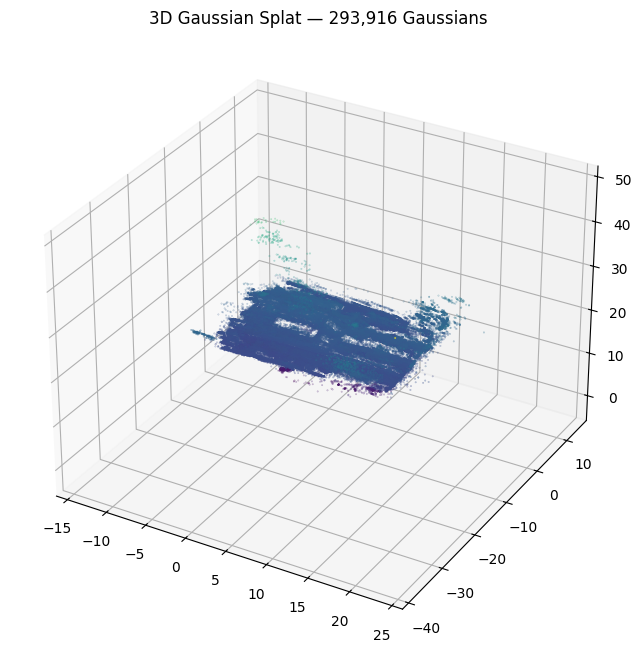

In [ ]:
# Visualize point cloud in Colab
import numpy as np
from plyfile import PlyData
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

ply = PlyData.read("output_room/point_cloud/iteration_7000/point_cloud.ply")
x = ply['vertex']['x']
y = ply['vertex']['y']
z = ply['vertex']['z']

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, c=z, cmap='viridis')
ax.set_title(f'3D Gaussian Splat — {len(x):,} Gaussians')
plt.savefig("point_cloud_viz.png", dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download("output_room/point_cloud/iteration_7000/point_cloud.ply")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>